# CFPB Customer Complaint - Exploratory Data Analysis

**Steps covered:**
1. Load the full CFPB complaint dataset
2. Analyze product distribution
3. Analyze narrative length (word count)
4. Identify complaints with / without narratives
5. Filter to 5 target products and remove empty narratives
6. Clean text narratives
7. Save cleaned dataset

In [1]:
import sys
import os

# Make sure the scripts folder is importable
sys.path.append(os.path.join(os.getcwd(), ".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from scripts.eda import EDA

%matplotlib inline
sns.set_theme(style="whitegrid")
print("Imports OK")

Imports OK


## 1. Load Data

In [2]:
DATA_PATH = "../data/complaints.csv"   # adjust if your file is named differently

eda = EDA(DATA_PATH)
eda.load_data()

Loaded dataset: 9,609,797 rows × 18 columns

Columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']

Sample rows:
  Date received                                            Product  \
0    2025-06-20  Credit reporting or other personal consumer re...   
1    2025-06-20                                    Debt collection   
2    2025-06-20  Credit reporting or other personal consumer re...   

               Sub-product                                 Issue  \
0         Credit reporting  Incorrect information on your report   
1  Telecommunications debt     Attempts to collect debt not owed   
2         Credit reporting           Improper use of your report   

                                       Sub-issue Con

In [3]:
# Quick overview
eda.df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9609797 entries, 0 to 9609796
Data columns (total 18 columns):
 #   Column                        Dtype
---  ------                        -----
 0   Date received                 str  
 1   Product                       str  
 2   Sub-product                   str  
 3   Issue                         str  
 4   Sub-issue                     str  
 5   Consumer complaint narrative  str  
 6   Company public response       str  
 7   Company                       str  
 8   State                         str  
 9   ZIP code                      str  
 10  Tags                          str  
 11  Consumer consent provided?    str  
 12  Submitted via                 str  
 13  Date sent to company          str  
 14  Company response to consumer  str  
 15  Timely response?              str  
 16  Consumer disputed?            str  
 17  Complaint ID                  int64
dtypes: int64(1), str(17)
memory usage: 1.3 GB


In [4]:
# Missing values per column
missing = eda.df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(eda.df) * 100).round(1)
pd.DataFrame({"Missing": missing, "Missing %": missing_pct}).head(10)

,Missing,Missing %
Tags,8981029,93.5
Consumer disputed?,8841498,92.0
Consumer complaint narrative,6629041,69.0
Company public response,4770207,49.6
Consumer consent provided?,1649561,17.2
Sub-issue,839522,8.7
Sub-product,235295,2.4
State,54516,0.6
ZIP code,30228,0.3
Company response to consumer,20,0.0


## 2. Product Distribution

/home/hp/Desktop/chatbot/Customer-Feedback-Chabot/notebooks/../scripts/eda.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="viridis")


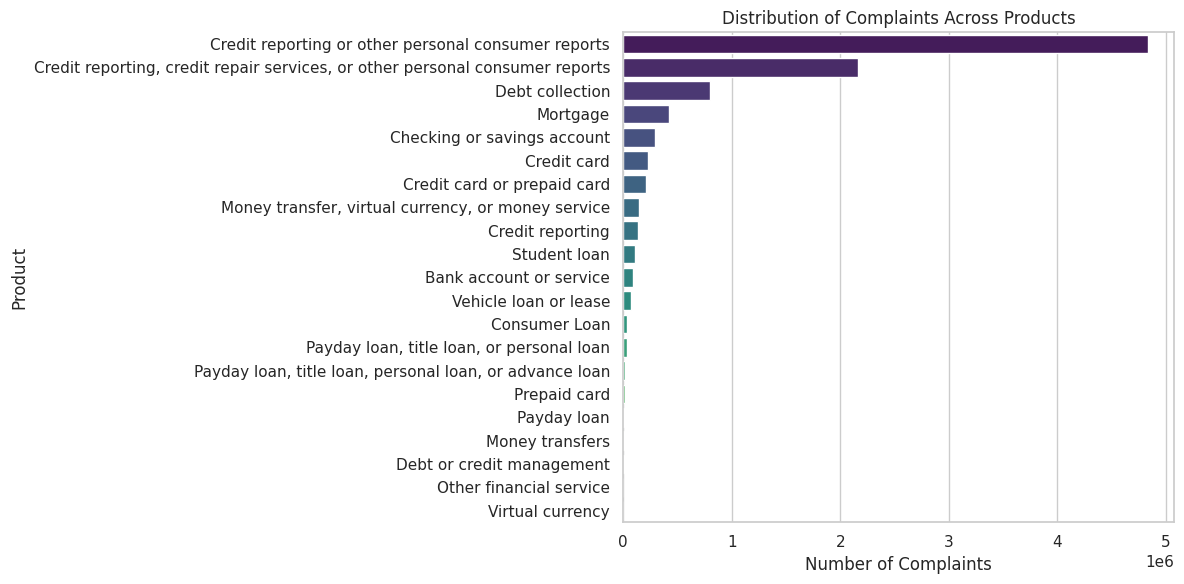


Product counts:
Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                           86205
Vehicle

In [5]:
eda.plot_product_distribution()

## 3. Narrative Length Analysis

Calculate the word count of each narrative and visualize the distribution.
Look for very short (< 20 words) or very long (> 500 words) narratives.


Narrative length statistics (word count):
count    2980756.0
mean         175.6
std          225.9
min            1.0
25%           59.0
50%          114.0
75%          209.0
max         6469.0
Name: narrative_length, dtype: float64

Very short narratives (< 20 words): 124,248
Very long narratives  (> 500 words): 160,989


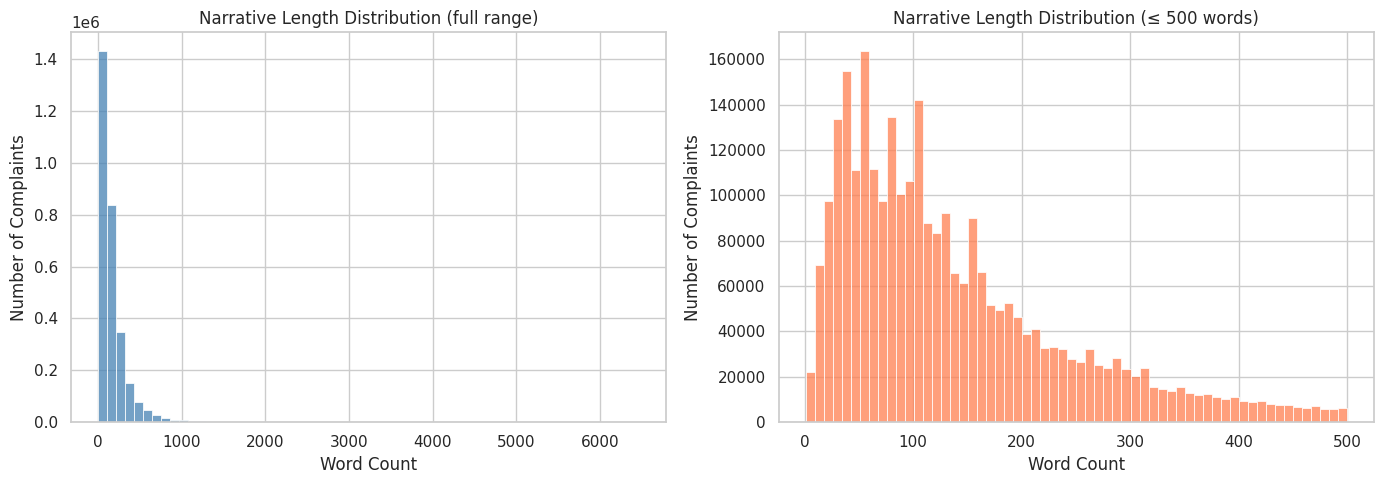

In [6]:
eda.analyze_narrative_length()

In [7]:
# Percentile breakdown
has_narrative = eda.df[eda.df["Consumer complaint narrative"].notna()]
percentiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
has_narrative["narrative_length"].quantile(percentiles).rename("word_count").to_frame()

,word_count
0.01,11.0
0.05,22.0
0.25,59.0
0.50,114.0
0.75,209.0
0.90,364.0
0.95,519.0
0.99,1021.0


## 4. Complaints With vs Without Narrative


With narrative   : 2,980,756  (31.0%)
Without narrative: 6,629,041  (69.0%)
Min length : 1 words
Max length : 6469 words


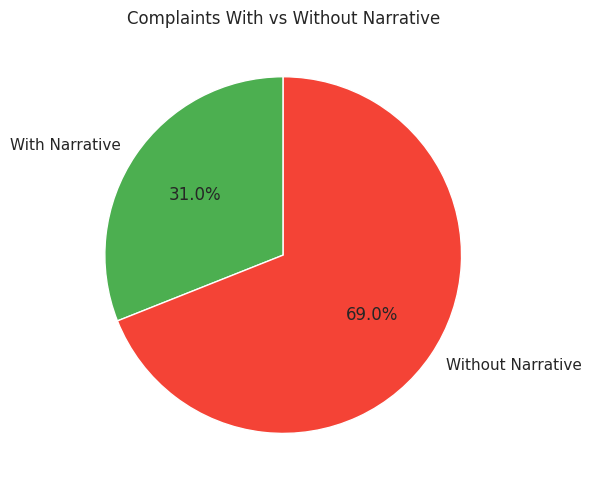

In [8]:
eda.narrative_presence()

## 5. Filter Dataset

Keep only the 5 target products and remove rows with empty narratives.

In [9]:
print("Target products:", EDA.ALLOWED_PRODUCTS)
eda.filter_data()

Target products: ['Credit card', 'Personal loan', 'Buy Now, Pay Later (BNPL)', 'Savings account', 'Money transfers']

Filtering:
  Rows before             : 9,609,797
  After product filter    : 232,040  (removed 9,377,757)
  After narrative filter  : 82,164  (removed 149,876)

Product distribution after filtering:
Product
Credit card        80667
Money transfers     1497


/tmp/ipykernel_24703/960416915.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


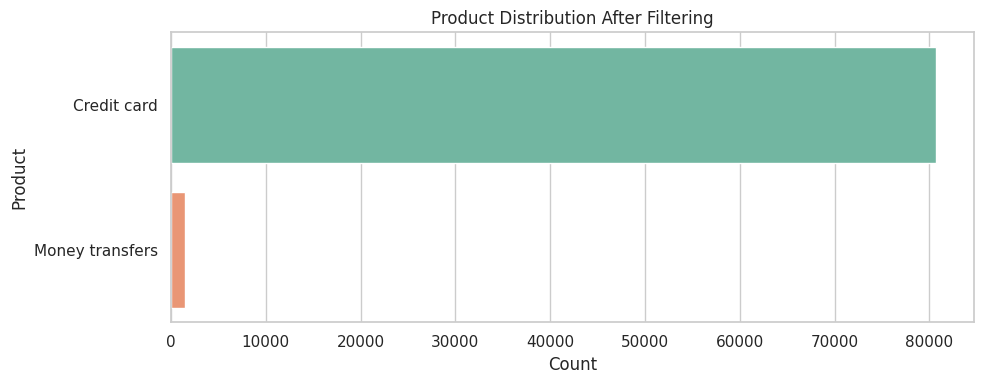

In [10]:
# Re-check product distribution after filtering
plt.figure(figsize=(10, 4))
sns.countplot(
    data=eda.df,
    y="Product",
    order=eda.df["Product"].value_counts().index,
    palette="Set2",
)
plt.title("Product Distribution After Filtering")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

## 6. Clean Text Narratives

Cleaning steps applied:
- Lowercase all text
- Remove CFPB redaction placeholder (`XXXX`)
- Remove common boilerplate phrases
- Remove special characters
- Normalize whitespace

In [11]:
eda.clean_narratives()


Sample cleaned narratives:

  [Original] A XXXX XXXX card was opened under my name by a fraudster. I received a notice from XXXX  that an account was just opened...
  [Cleaned]  a card was opened under my name by a fraudster i received a notice from that an account was just opened under my name i ...

  [Original] Dear CFPB, I have a secured credit card with citibank which is changed to unsecured card and I have been calling n waitt...
  [Cleaned]  dear cfpb i have a secured credit card with citibank which is changed to unsecured card and i have been calling n waitti...

  [Original] I have a Citi rewards cards. The credit balance issued to me was {$8400.00}. I recently moved, which meant my bills woul...
  [Cleaned]  i have a citi rewards cards the credit balance issued to me was 8400 00 i recently moved which meant my bills would be l...

Cleaned length stats:
count    82164.0
mean       190.5
std        207.7
min          0.0
25%         60.0
50%        136.0
75%        249.0
max  

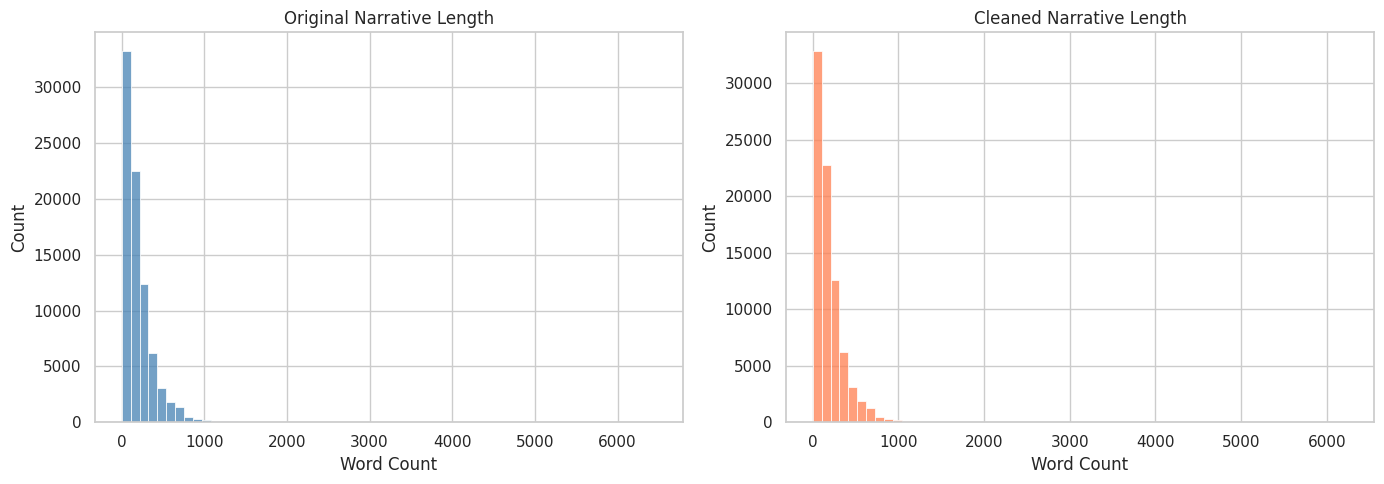

In [12]:
# Compare original vs cleaned length
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(eda.df["narrative_length"], bins=60, ax=axes[0], color="steelblue")
axes[0].set_title("Original Narrative Length")
axes[0].set_xlabel("Word Count")

sns.histplot(eda.df["cleaned_length"], bins=60, ax=axes[1], color="coral")
axes[1].set_title("Cleaned Narrative Length")
axes[1].set_xlabel("Word Count")

plt.tight_layout()
plt.show()

## 7. Save Cleaned Data

In [13]:
eda.save_cleaned_data("../data/cleaned_complaints.csv")
eda.df[["Product", "Consumer complaint narrative", "cleaned_narrative", "cleaned_length"]].head(5)


Cleaned data saved to: ../data/cleaned_complaints.csv  (82,164 rows)


,Product,Consumer complaint narrative,cleaned_narrative,cleaned_length
12237,Credit card,A XXXX XXXX card was opened under my name by a...,a card was opened under my name by a fraudster...,82
13280,Credit card,"Dear CFPB, I have a secured credit card with c...",dear cfpb i have a secured credit card with ci...,158
13506,Credit card,I have a Citi rewards cards. The credit balanc...,i have a citi rewards cards the credit balance...,229
13955,Credit card,b'I am writing to dispute the following charge...,b i am writing to dispute the following charge...,469
14249,Credit card,"Although the account had been deemed closed, I...",although the account had been deemed closed i ...,163


---
## Summary

| Step | Result |
|------|--------|
| Raw dataset loaded | ✅ |
| Product distribution visualized | ✅ |
| Narrative length analyzed | ✅ |
| Narratives with/without identified | ✅ |
| Filtered to 5 products + non-empty narrative | ✅ |
| Text cleaned (lowercase, boilerplate removed) | ✅ |
| Cleaned data saved | ✅ |